In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# LOAD DATA

In [3]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# EDA

### Shape

In [4]:
print(df.shape)

(42000, 785)


### Visualisasi Digit

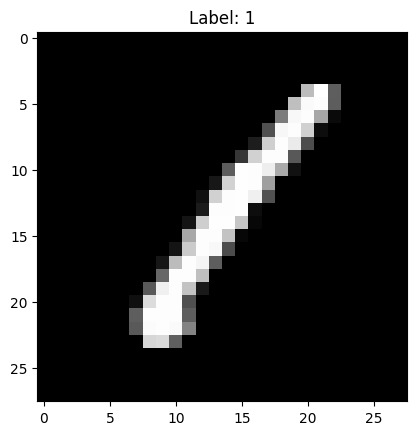

In [5]:
img = df.iloc[0, 1:].values.reshape(28,28)

plt.imshow(img, cmap='gray')
plt.title(f"Label: {df.iloc[0,0]}")
plt.show()

### Distribusi Label

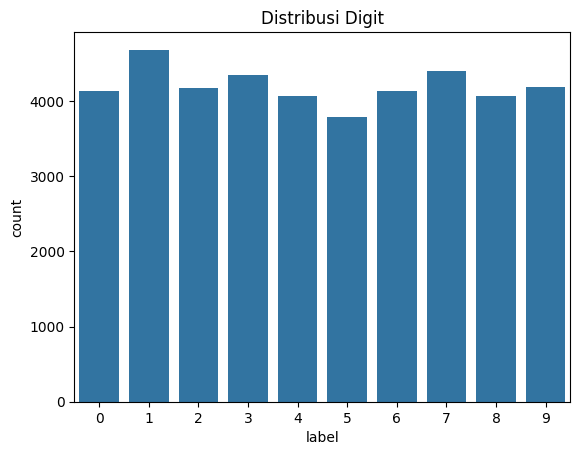

In [6]:
sns.countplot(x='label', data=df)
plt.title('Distribusi Digit')
plt.show()

# PREPROCESSING

### Splitt x & y

In [7]:
X = df.drop('label', axis=1)
y = df['label']

### Normalisasi

In [8]:
X = X / 255.0

### Split Train Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# BASELINE ML

### PCA

In [10]:
pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

### SVM

In [11]:
start = time.time()

svm = SVC()
svm.fit(X_train_pca, y_train)

svm_time = time.time() - start

pred_svm = svm.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("SVM Time:", svm_time)

SVM Accuracy: 0.9777380952380952
SVM Time: 18.82117533683777


### RANDOM FOREST

In [14]:
start = time.time()

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_pca, y_train)

rf_time = time.time() - start

pred_rf = rf.predict(X_test_pca)

print("RF Accuracy:", accuracy_score(y_test, pred_rf))
print("RF Time:", rf_time)

RF Accuracy: 0.9475
RF Time: 62.891587018966675


# CONFUSSION MATRIX ML

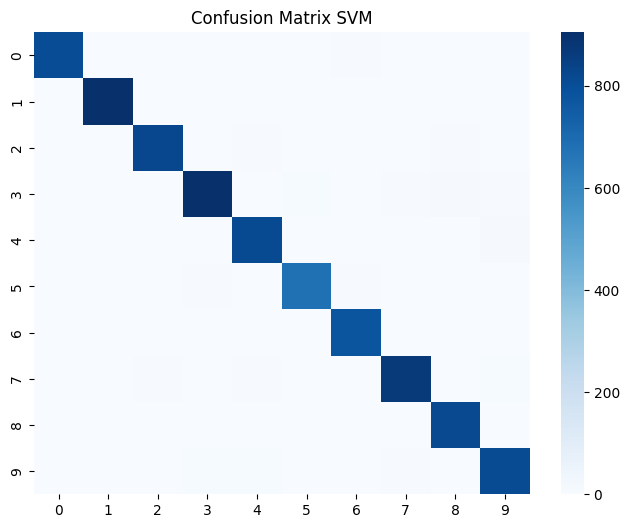

In [12]:
cm_svm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=False, cmap='Blues')
plt.title("Confusion Matrix SVM")
plt.show()

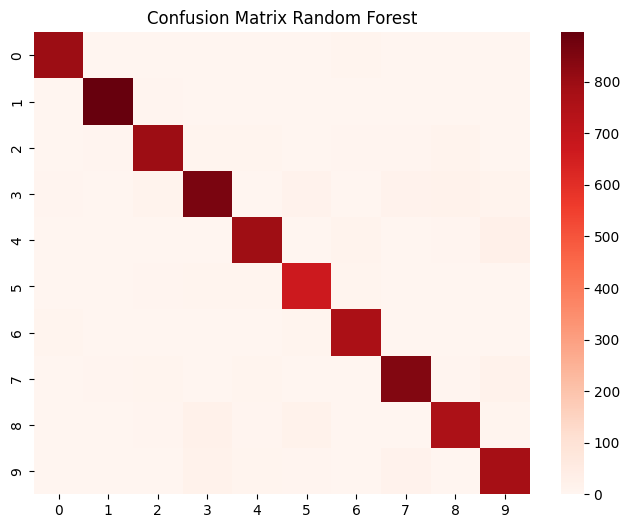

In [15]:
cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=False, cmap='Reds')
plt.title("Confusion Matrix Random Forest")
plt.show()

# DEEP LEARNING (CNN)

In [16]:
X_train_cnn = X_train.values.reshape(-1,28,28,1)
X_test_cnn = X_test.values.reshape(-1,28,28,1)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [18]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
start = time.time()

model.fit(X_train_cnn, y_train, epochs=5, batch_size=32)

cnn_time = time.time() - start

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step - accuracy: 0.9460 - loss: 0.1771
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.9824 - loss: 0.0556
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.9879 - loss: 0.0372
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.9906 - loss: 0.0277
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9931 - loss: 0.0205


In [21]:
loss, acc = model.evaluate(X_test_cnn, y_test)

print("CNN Accuracy:", acc)
print("CNN Time:", cnn_time)

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9840 - loss: 0.0566
CNN Accuracy: 0.9840475916862488
CNN Time: 182.230566740036


263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step


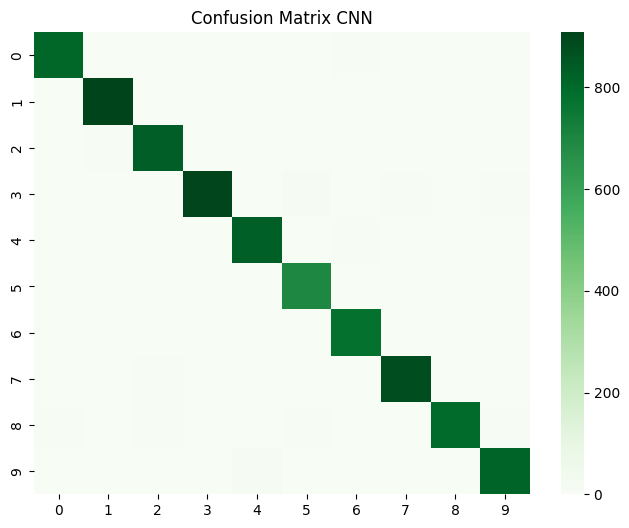

In [22]:
pred_cnn = model.predict(X_test_cnn)
pred_cnn = np.argmax(pred_cnn, axis=1)

cm_cnn = confusion_matrix(y_test, pred_cnn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=False, cmap='Greens')
plt.title("Confusion Matrix CNN")
plt.show()

# ERROR ANALYSIS

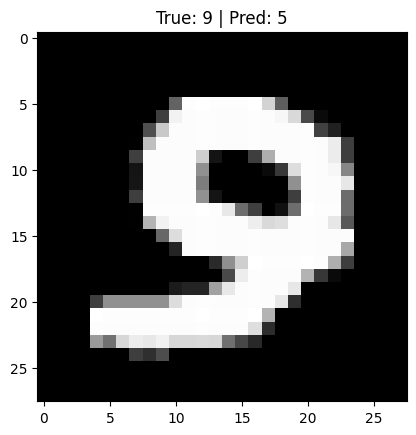

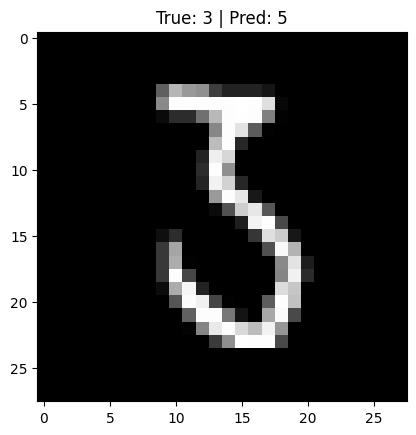

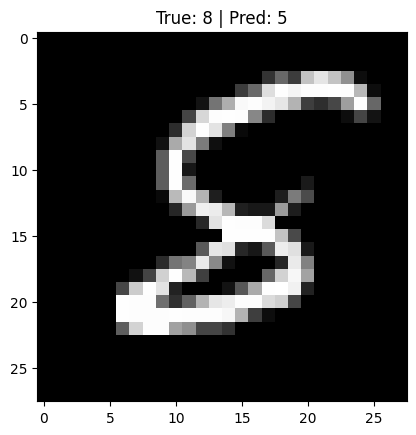

In [23]:
wrong = np.where(pred_cnn != y_test)[0]

for i in range(3):
    idx = wrong[i]

    plt.imshow(X_test.iloc[idx].values.reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test.iloc[idx]} | Pred: {pred_cnn[idx]}")
    plt.show()

# FINAL RESULT

In [24]:
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("RF Accuracy:", accuracy_score(y_test, pred_rf))
print("CNN Accuracy:", acc)

print("SVM Time:", svm_time)
print("RF Time:", rf_time)
print("CNN Time:", cnn_time)

SVM Accuracy: 0.9777380952380952
RF Accuracy: 0.9475
CNN Accuracy: 0.9840475916862488
SVM Time: 18.82117533683777
RF Time: 62.891587018966675
CNN Time: 182.230566740036
